# Тимски проект: Споредба на алгоритмите за предвидување на временски серии
**Dataset:** PJME Hourly Energy Consumption

**Студенти:**

*   Амел Махмутовиќ (203100)
*   Христина Степаноска (183007)
*   Михаела Николовска (183014)




## 1. Вовед и опис на множеството
Во оваа тетратка се анализира часовната потрошувачка на електрична енергија користејќи го множеството податоци PJME Hourly Energy Consumption. Целта на анализата е да се изгради модел за предвидување на идната побарувачка на електрична енергија и да се направи споредба помеѓу различни пристапи за предвидување: базични модели, класични модели за временски серии и модели од машинско учење.

Множеството податоци ги содржи следните променливи:

*   Datetime – временска ознака на часовно ниво
*   PJME_MW – потрошувачка на електрична енергија изразена во мегавати (MW)

## 2. Вчитување и препроцесирање на податоците


Во оваа секција ги вчитуваме податоците, ги конвертираме временските ознаки во datetime формат и ја поставуваме временската колона како индекс. Податоците се сортираат по време за да се обезбеди коректна временска анализа.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
import xgboost as xgb

In [34]:
plt.rcParams['figure.figsize'] = (14,5)
np.random.seed(42)

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df = pd.read_csv('/content/drive/MyDrive/hourly-energy-consumption/PJME_hourly.csv')

In [37]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()

In [38]:
df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('h')

In [39]:
df.isna().sum()

,0
PJME_MW,30


In [40]:
df = df.dropna()

In [41]:
df

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
...,...
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0


In [42]:
df.isna().sum()

,0
PJME_MW,0


In [43]:
df.describe()

,PJME_MW
count,145362.000000
mean,32080.510780
std,6463.866507
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## 3. Експлораторна анализа на податоците (EDA)

Целта на експлораторната анализа (EDA) е да се идентификуваат основните карактеристики на временската серија, како што се долгорочниот тренд, дневната и неделната сезоналност и варијабилноста на потрошувачката во различни временски периоди.

###3.1 Целосна временска серија

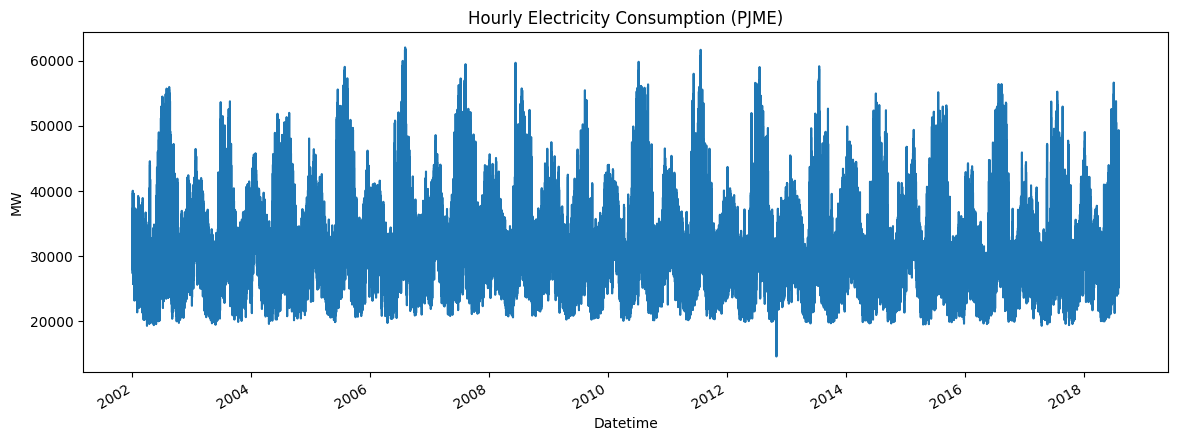

In [44]:
df['PJME_MW'].plot(title='Hourly Electricity Consumption (PJME)')
plt.ylabel('MW')
plt.show()

###3.2 Преглед на една недела

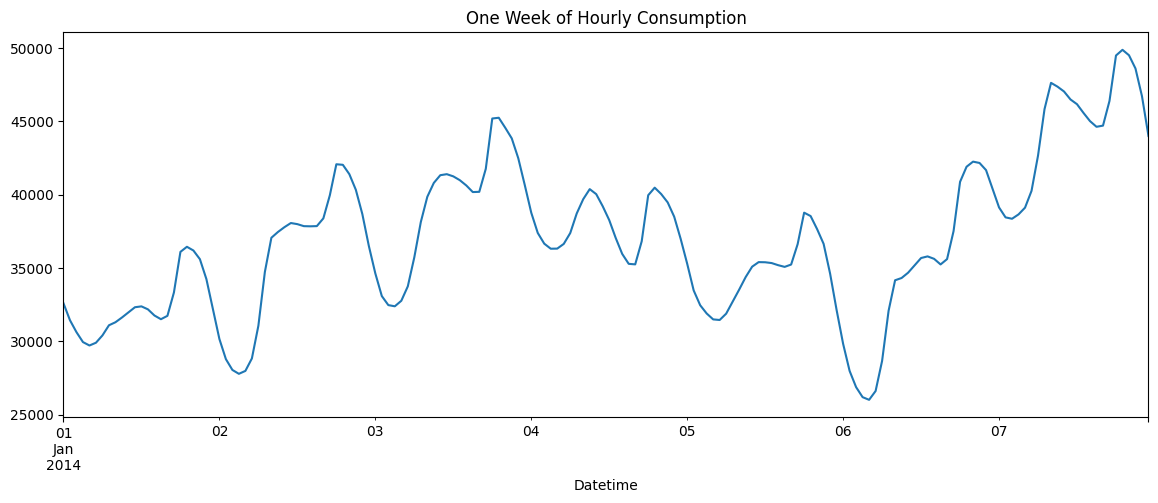

In [45]:
df.loc['2014-01-01':'2014-01-07', 'PJME_MW'].plot(title='One Week of Hourly Consumption')
plt.show()

###3.3 Просечна потрошувачка по час

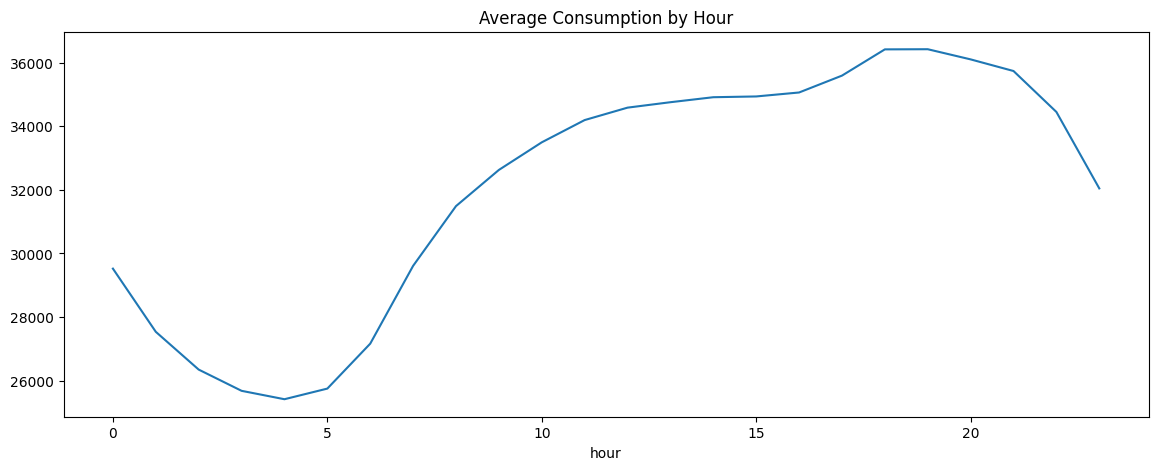

In [46]:
df['hour'] = df.index.hour
df.groupby('hour')['PJME_MW'].mean().plot(title='Average Consumption by Hour')
plt.show()

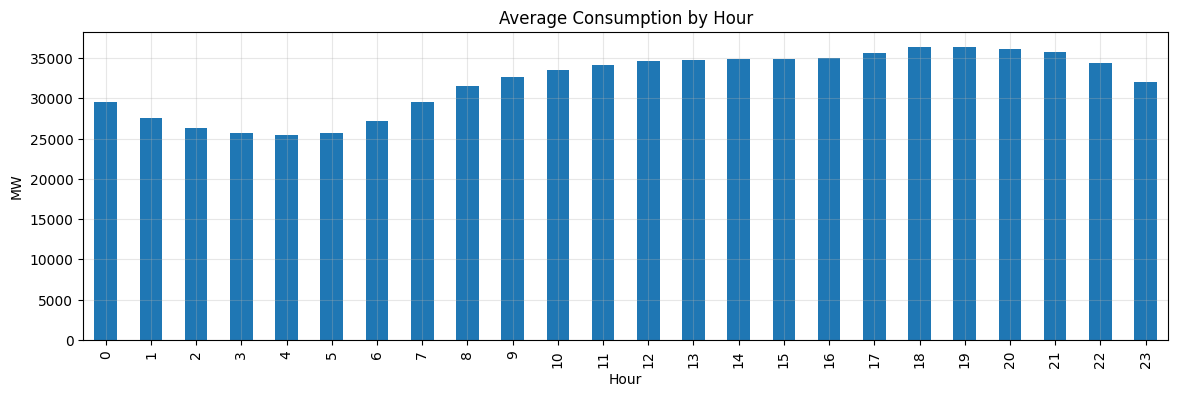

In [47]:
df.groupby('hour')['PJME_MW'].mean().plot(
    kind='bar', figsize=(14,4)
)
plt.title('Average Consumption by Hour')
plt.xlabel('Hour')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()

###3.4 Просечна потрошувачка по ден во неделата

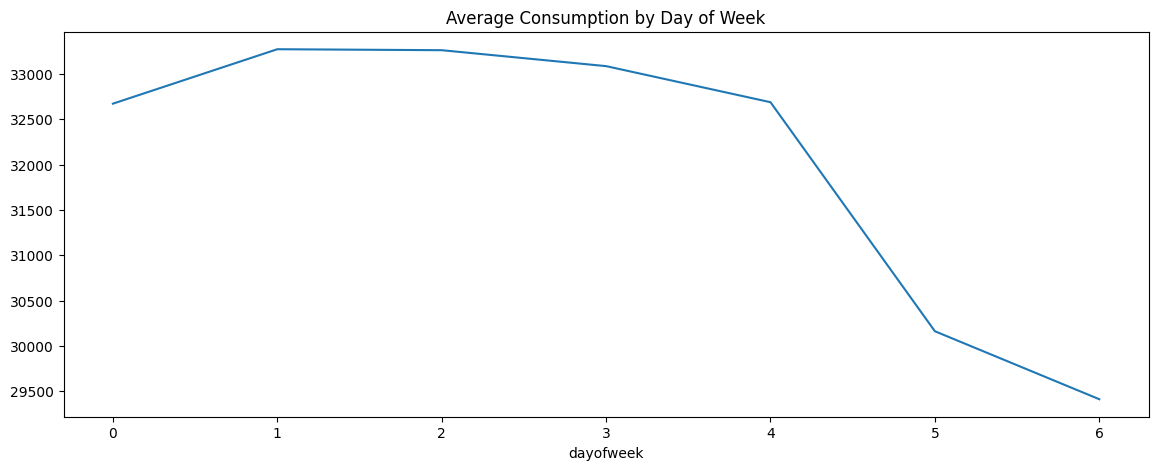

In [48]:
df['dayofweek'] = df.index.dayofweek
df.groupby('dayofweek')['PJME_MW'].mean().plot(title='Average Consumption by Day of Week')
plt.show()

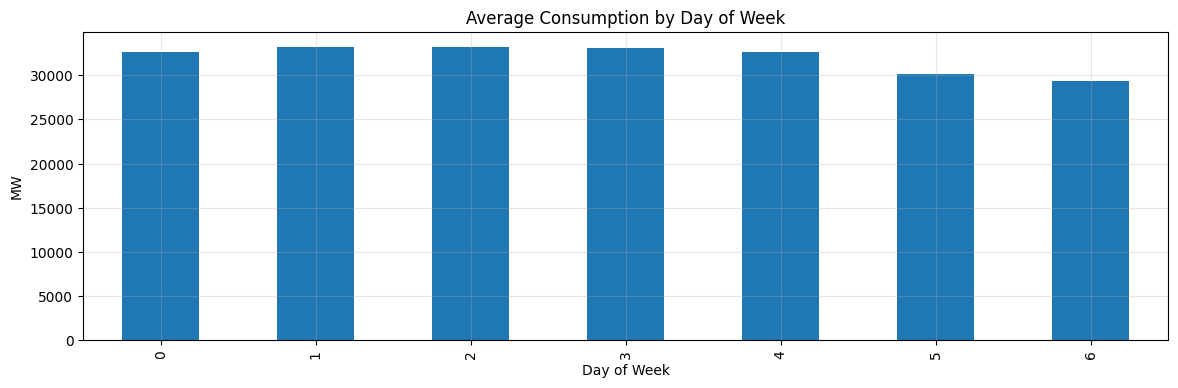

In [49]:
df.groupby('dayofweek')['PJME_MW'].mean().plot(
    kind='bar', figsize=(14,4)
)
plt.title('Average Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()

###3.5 Просечна потрошувачка по месец

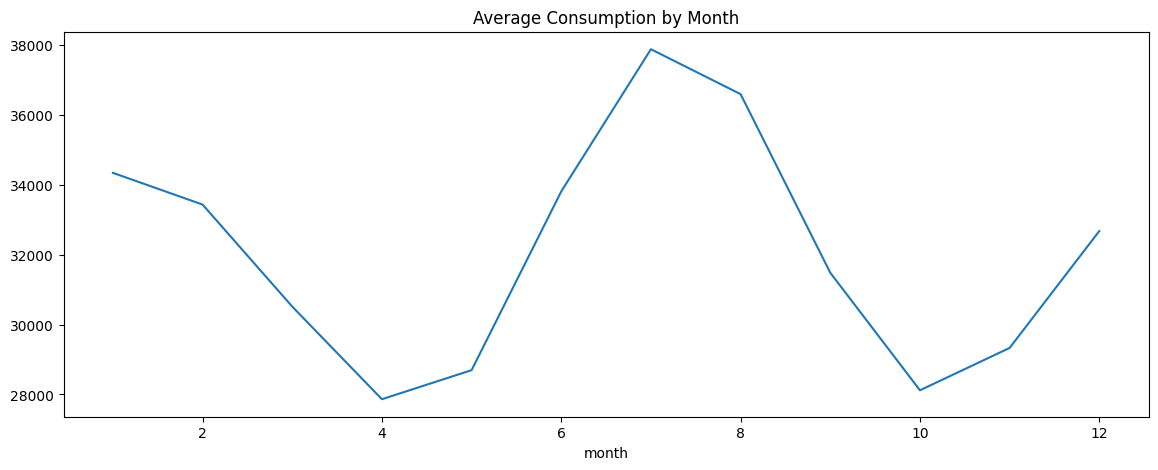

In [50]:
df['month'] = df.index.month
df.groupby('month')['PJME_MW'].mean().plot(title='Average Consumption by Month')
plt.show()

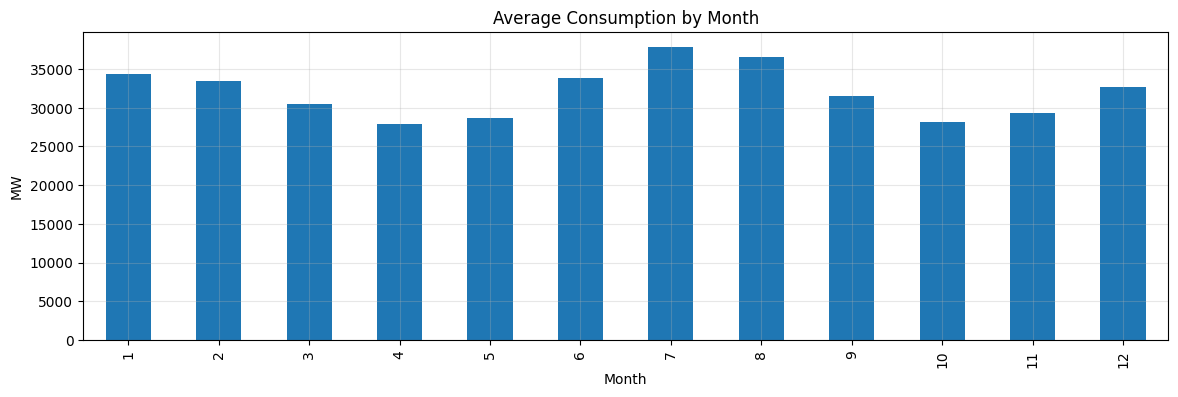

In [51]:
df.groupby('month')['PJME_MW'].mean().plot(
    kind='bar', figsize=(14,4)
)
plt.title('Average Consumption by Month')
plt.xlabel('Month')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()

###3.6 Долгорочен тренд

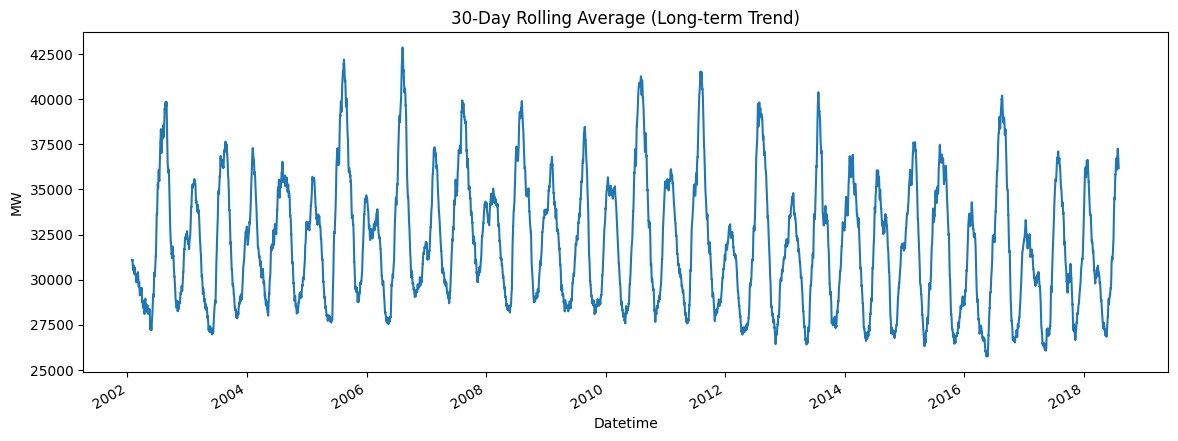

In [52]:
df['PJME_MW'].rolling(24*30).mean().plot(title='30-Day Rolling Average (Long-term Trend)')
plt.ylabel('MW')
plt.show()

###3.7 Работни денови vs Викенди

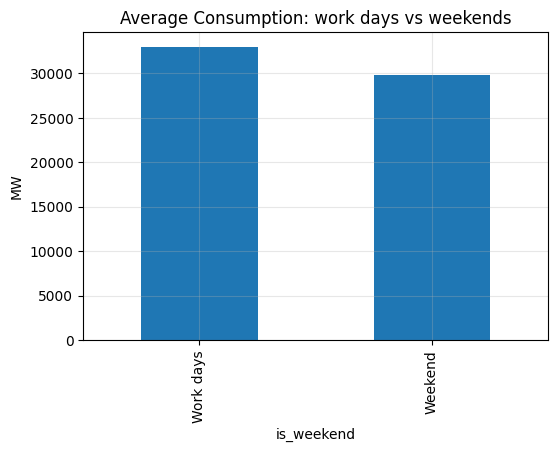

In [53]:
df['is_weekend'] = df.index.dayofweek >= 5

df.groupby('is_weekend')['PJME_MW'].mean().plot(
    kind='bar', figsize=(6,4)
)

plt.xticks([0,1], ['Work days', 'Weekend'])
plt.title('Average Consumption: work days vs weekends')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()

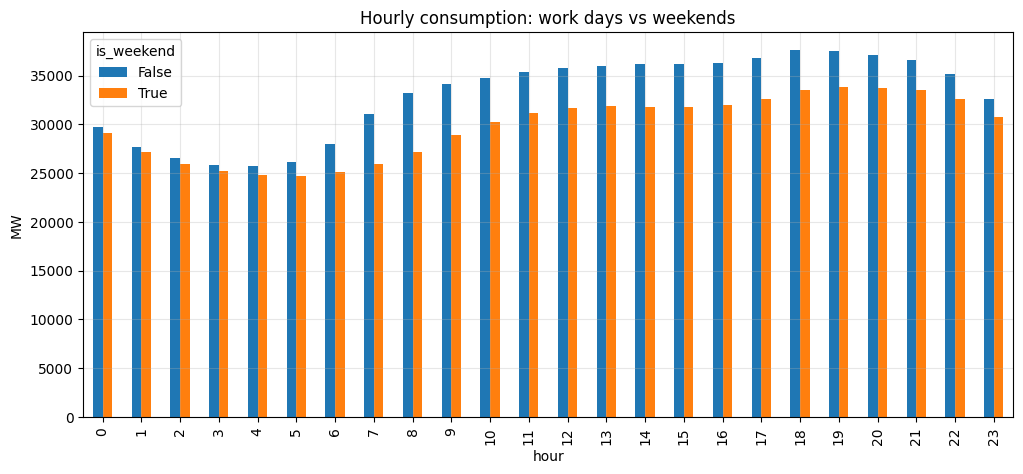

In [54]:
hourly_weekend = df.groupby(['hour', 'is_weekend'])['PJME_MW'].mean().unstack()

hourly_weekend.plot(kind='bar', figsize=(12,5))
plt.title('Hourly consumption: work days vs weekends')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()


Пониската потрошувачка за време на викендите е очекувана поради намалена индустриска и деловна активност.

###3.8 Лето vs Зима

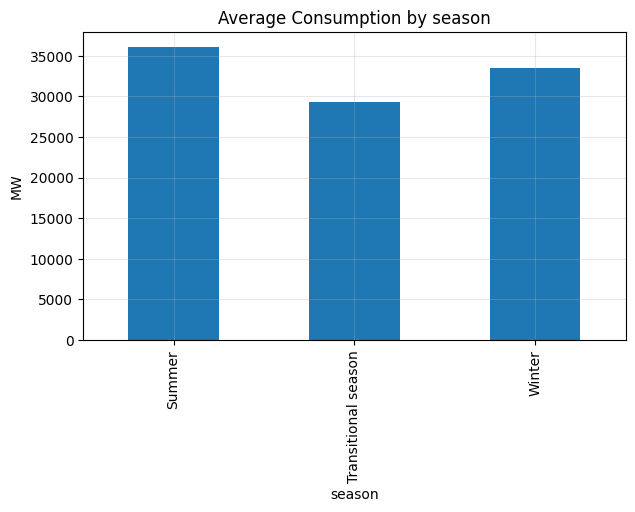

In [55]:
def season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Transitional season'

df['season'] = df.index.month.map(season)

df.groupby('season')['PJME_MW'].mean().plot(
    kind='bar', figsize=(7,4)
)

plt.title('Average Consumption by season')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()
df = df.drop(columns=['season'], errors='ignore')

Се забележува повисока потрошувачка во лето и зима, што може да се поврзе со користење на клима уреди и системи за греење.

## 4. Декомпозиција на временската серија

Со сезонска декомпозиција ја делиме серијата на:


* Тренд – долгорочно движење на потрошувачката
* Сезоналност – повторливи дневни шаблони (24 часа)
* Резидуали – случајни отстапувања

###4.1 Дневна сезоналност

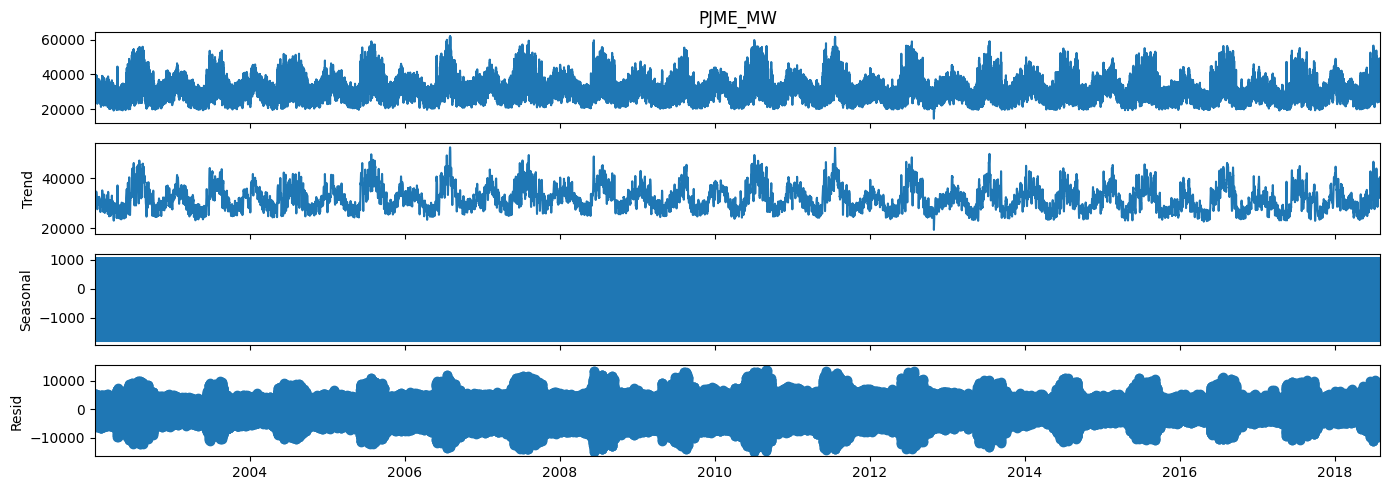

In [56]:
decomposition_daily = seasonal_decompose(
    df['PJME_MW'], model='additive', period=24)
decomposition_daily.plot()
plt.show()

###4.2 Неделна сезоналност

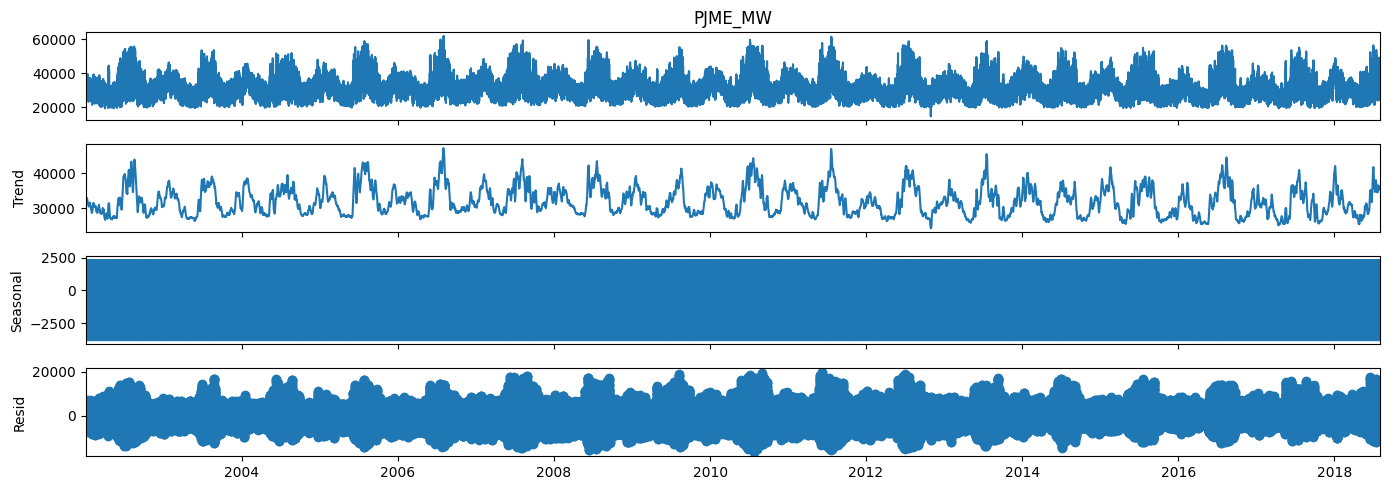

In [57]:
decomposition_weekly = seasonal_decompose(
    df['PJME_MW'], model='additive', period=168)
decomposition_weekly.plot()
plt.show()

## 5. Основни (Baseline) модели

Се користат Naive пристапи (Lag-1 и Seasonal Lag-24) како референтна точка за споредба. Овие модели се едноставни, но важни за проценка дали посложените модели носат реално подобрување.

###5.1 Naïve Forecast (Lag-1)

Се претпоставува дека потрошувачката во тековниот час е иста како во претходниот.

In [58]:
df['lag_1'] = df['PJME_MW'].shift(1)

###5.2 Seasonal Naïve Forecast (Lag-24)

Се користи вредноста од истиот час претходниот ден.

In [59]:
df['lag_24'] = df['PJME_MW'].shift(24)

## 6. Класични модели (ARIMA и Prophet)

Податоците се делат на train и test множество. Се тренираат ARIMA и Prophet модели кои ја моделираат временската структура и сезоналноста на серијата.

###6.1 Train/Test Split

In [60]:
split_date = '2015-01-01'

train = df[df.index < split_date]
test  = df[df.index >= split_date]

###6.2 ARIMA

ARIMA моделот ја користи автокорелацијата во податоците, но без експлицитно моделирање на сезоналност, што може да доведе до послаби резултати кај силно сезонски серии.

In [61]:
arima_model = ARIMA(train['PJME_MW'], order=(1,0,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/pyth

###6.3 Prophet

Prophet моделот овозможува автоматско моделирање на тренд, дневна, неделна и годишна сезоналност и e соодветен за овој тип податоци.

In [62]:
prophet_df = train.reset_index()[['Datetime', 'PJME_MW']]
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

In [63]:
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=len(test), freq='h')
forecast = prophet_model.predict(future)

prophet_pred = forecast.iloc[-len(test):]['yhat'].values

## 7. Машинско учење

###Feature Engineering за XGBoost

Моделите од машинско учење не ја користат временската структура директно, па затоа се креираат:

* лагирани карактеристики (1, 24, 168 часа)
* rolling статистики (просек и стандардна девијација)


In [64]:
df['lag_1']   = df['PJME_MW'].shift(1)
df['lag_24']  = df['PJME_MW'].shift(24)
df['lag_168'] = df['PJME_MW'].shift(168)

In [65]:
df['rolling_mean_24'] = df['PJME_MW'].shift(1).rolling(24).mean()
df['rolling_std_24'] = df['PJME_MW'].shift(1).rolling(24).std()

In [66]:
df_ml = df.dropna()

In [67]:
print(len(test['PJME_MW']), len(df['lag_1'].dropna()))


31437 145361


In [68]:
train_ml = df_ml[df_ml.index < split_date]
test_ml = df_ml[df_ml.index >= split_date]

In [69]:
X_train = train_ml.drop(columns=['PJME_MW'])
y_train = train_ml['PJME_MW']
X_test = test_ml.drop(columns=['PJME_MW'])
y_test = test_ml['PJME_MW']

####XGBoost Model

XGBoost е моќен tree-based модел кој добро се справува со нелинеарни односи и комплексни шаблони во податоците.

In [70]:
xgb_model = xgb.XGBRegressor(
  n_estimators=300,
  learning_rate=0.05,
  max_depth=6,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42
)

In [71]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

##8. Евалуација на моделите

Моделите се споредуваат со следните метрики:

* MAE (Mean Absolute Error) – просечна апсолутна грешка
* RMSE (Root Mean Squared Error) – чувствителна на големи грешки
* MAPE (Mean Absolute Percentage Error)– просечна апсолутна процентуална грешка
* R² (Coefficient of Determination) – варијанса


In [72]:
def mape(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(y_true, y_pred):
  return {
      'MAE': mean_absolute_error(y_true, y_pred),
      'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
      'MAPE': mape(y_true, y_pred),
      'R2': r2_score(y_true, y_pred)
  }

In [85]:
results = []

lag1_pred = df.loc[test.index, 'lag_1']

results.append({'Model': 'Naive (Lag-1)', **evaluate(test['PJME_MW'], lag1_pred)})
results.append({'Model': 'ARIMA', **evaluate(test['PJME_MW'], arima_pred)})
results.append({'Model': 'Prophet', **evaluate(test['PJME_MW'], prophet_pred)})
results.append({'Model': 'XGBoost', **evaluate(y_test, y_pred_xgb)})

/tmp/ipython-input-3318417573.py:2: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [86]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,MAPE,R2
0,Naive (Lag-1),1062.579985,1366.066657,3.434025,0.955133
1,ARIMA,5254.929477,6521.234424,NaN,-0.022449
2,Prophet,3747.436649,4847.822911,11.873593,0.434965
3,XGBoost,363.510140,483.678515,1.149485,0.994375


###8.1 XGBoost – Actual vs Predicted

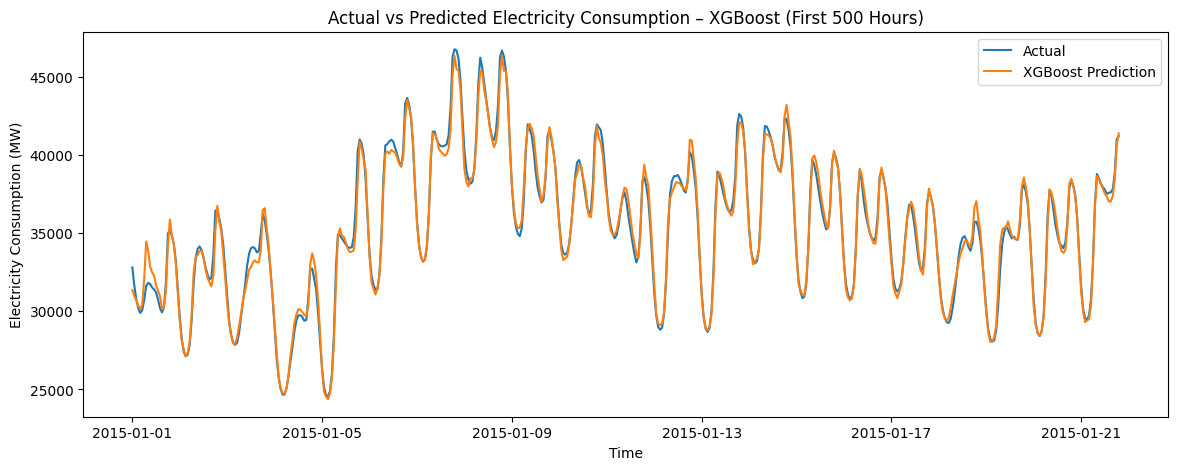

In [75]:
plt.figure(figsize=(14,5))
plt.plot(
    y_test.index[:500],
    y_test.values[:500],
    label='Actual'
)
plt.plot(
    y_test.index[:500],
    y_pred_xgb[:500],
    label='XGBoost Prediction',
)

plt.legend()
plt.title('Actual vs Predicted Electricity Consumption – XGBoost (First 500 Hours)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.show()

XGBoost најпрецизно ги следи реалните вредности и ги фаќа дневните пикови и падови.

###8.2 ARIMA – Actual vs Predicted

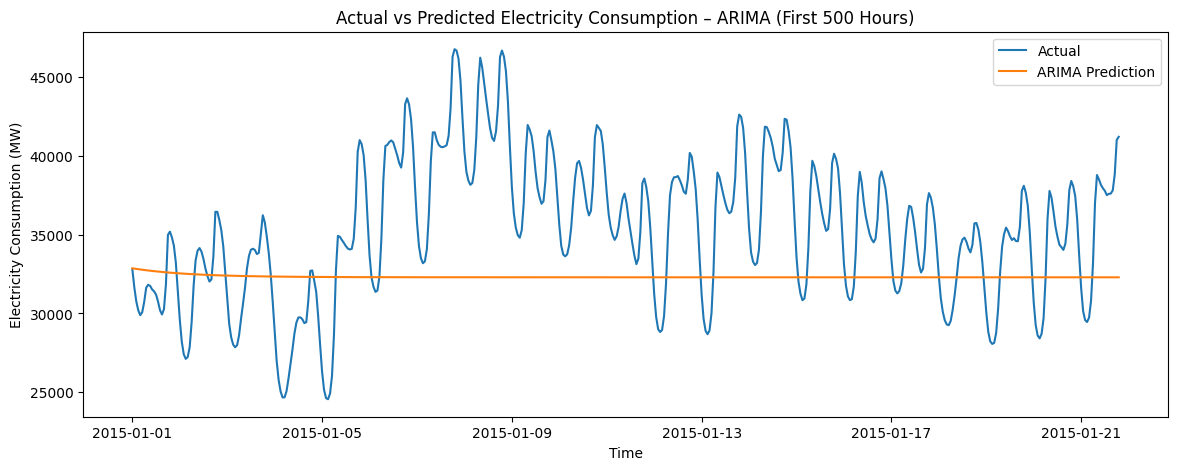

In [76]:
plt.figure(figsize=(14,5))
plt.plot(
    y_test.index[:500],
    y_test.values[:500],
    label='Actual'
)
plt.plot(
    y_test.index[:500],
    arima_pred[:500],
    label='ARIMA Prediction'
)

plt.legend()
plt.title('Actual vs Predicted Electricity Consumption – ARIMA (First 500 Hours)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.show()

ARIMA не успева да ја моделира сложената сезоналност на часовните податоци и покажува значителни отстапувања.

###8.3 Prophet – Actual vs Predicted

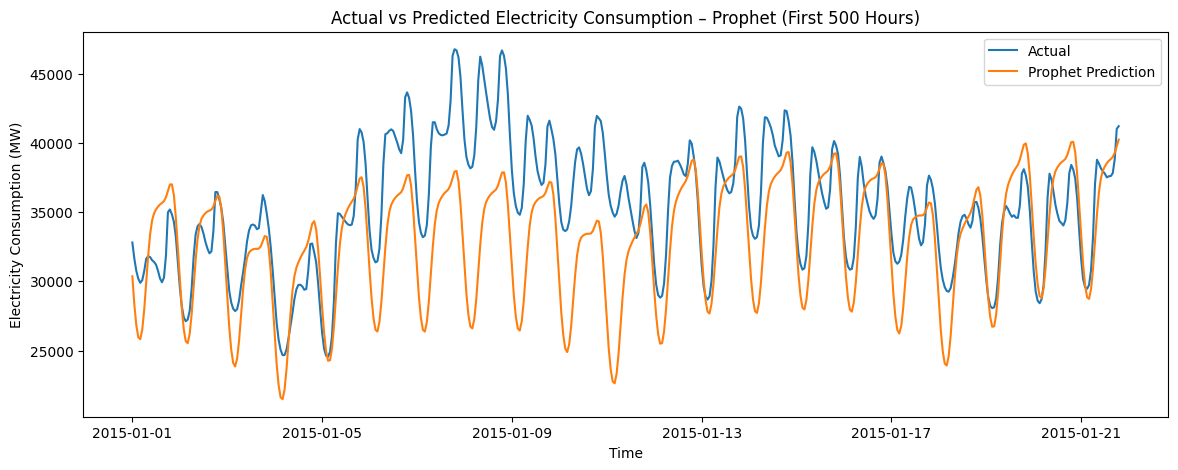

In [77]:
plt.figure(figsize=(14,5))
plt.plot(
    y_test.index[:500],
    y_test.values[:500],
    label='Actual'
)
plt.plot(
    y_test.index[:500],
    prophet_pred[:500],
    label='Prophet Prediction'
)

plt.legend()
plt.title('Actual vs Predicted Electricity Consumption – Prophet (First 500 Hours)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.show()

Prophet добро го идентификува долгорочниот тренд и повторливите сезонски обрасци, но не успева прецизно да ги следи брзите и ненадејни промени во часовната потрошувачка.

###8.4 Финална споредба на грешки (MAE, RMSE, MAPE)

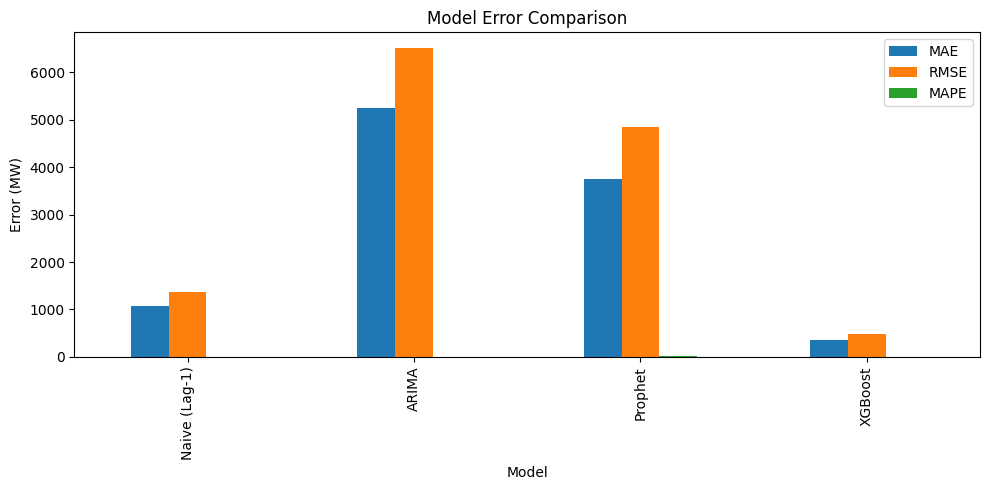

In [83]:
results_df.set_index('Model')[['MAE','RMSE', 'MAPE']].plot(kind='bar', figsize=(10,5))
plt.title('Model Error Comparison')
plt.ylabel('Error (MW)')
plt.tight_layout()
plt.show()

##9. Заклучок

Во проектот беше извршена детална анализа на часовната потрошувачка на електрична енергија. Базичните модели обезбедуваат референтна точка, класичните модели покажуваат подобрување преку експлицитно моделирање на сезоналност, додека XGBoost моделот постигнува најдобри резултати со најмала грешка.

Резултатите укажуваат дека изборот на модел зависи од компромисот помеѓу интерпретабилност и точност, при што XGBoost е најсоодветен за прецизно предвидување, а класичните модели за анализа и разбирање на структурата на податоците.

###9.1 Naive (Lag-1)

Наивниот модел користи вредност од претходниот час како предвидување. Иако е многу едноставен, покажува солидни резултати со ниски MAE и RMSE вредности и висок R². Ова укажува дека потрошувачката има силна краткорочна зависност, односно дека соседните часови често имаат слични вредности.

###9.2 ARIMA

ARIMA моделот покажува најлоши резултати меѓу сите модели. Високите вредности на MAE и RMSE и негативната R² вредност, покажуваат дека моделот не успева добро да ја објасни варијансата во податоците. ARIMA моделите се чувствителни на комплексна сезоналност и често не се доволни за часовни податоци.

###9.3 Prophet

Prophet моделот има подобри резултати од ARIMA, но сè уште е значително полош од наивниот и XGBoost моделот. Моделот добро го фаќа долгорочниот тренд и сезоналноста, но често не ги погодува наглите промени од еден час во друг, како утринските и вечерните пикови во потрошувачката.

###9.4 XGBoost

XGBoost моделот постигнува најдобри резултати според сите метрики. Има најниски MAE, RMSE и MAPE вредности и највисок R². Ова покажува дека моделот успешно ги користи дополнителните карактеристики (lag вредности и rolling статистики) и добро ги моделира нелинеарните односи во податоците. Поради тоа, XGBoost се покажува како најсоодветен модел за ова податочно множество.